# Magnetic Susceptibility Data
One important aim of the Koh Ker Pilot Project in July of 2024 (KKPP24) was to determine whether magentic susceptibility along the depth (from modern to archaeologically sterile layers) of a given profile wall in each of eight excavated trenches correlated with the presence/absence of artifacts and other evidence of human activity in each trench.

At each trench, I scanned a selected profile wall with a handheld KT-20 magentic susceptibility console using a 10KHz scanner. The scanner can be used ina continuous scan mode that collects and averages 4 readings every 0.25 seconds. So, we set up a digital metronome to help maintain a consistent pace for the scan and then started the scan at 0cm (modern surface) and ended the scan at the bottom of the trench. This was repeated at least 4 times in each trench in order to evaluate scan variability and produce the best, most consistent final data set. The process was then repeated for each of the 8 trenches we excavated.

In this workbook, I import the raw magnetic susceptibility data from the scans taken during the KKPP24 fieldwork season. I then add minimum and maximum depth data to the scan sequences and subsample/interpolate the scans onto a consistent set of depths below the modern surface for each trench. Lastly, I plot the data.

In [16]:
# libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [15]:
# Function to read the mapping from Excel
def read_mapping_from_excel(file_path):
    # Read the Excel file, assuming the mapping is in the first sheet
    mapping_df = pd.read_excel(file_path, sheet_name=0)
    
    # Create a dictionary mapping MagSusRecord to Trench
    record_to_trench_map = dict(zip(mapping_df['MagSusRecord'], mapping_df['Trench']))
    
    return record_to_trench_map

# Function to process a single CSV file
def process_csv(file_path, record_id, record_to_trench_map):
    # Read the CSV file, skipping first two and last three lines
    data = pd.read_csv(file_path, skiprows=3, skipfooter=3, engine='python')
    
    # Extract relevant columns
    data = data.iloc[:, [0, 1]]  # Columns: scan_idx and susceptibility
    data.columns = ['scan_idx', 'susceptibility']
    
    # Add Record_ID and Trench_ID
    data['record_id'] = record_id
    data['trench_id'] = record_to_trench_map.get(record_id, 'Unknown')
    
    return data[['record_id', 'trench_id', 'scan_idx', 'susceptibility']]

# Read the mapping from the Excel file
excel_path = '../Data/MagSusMap.xlsx'
record_to_trench_map = read_mapping_from_excel(excel_path)

# List of files and corresponding record IDs
files = []

# Base path for the data folder
base_path = '../Data/kt20_0467/'

# Loop over each row in the mapping DataFrame
for record_number in record_to_trench_map.keys():
    folder_name = f"{record_number}"     # Create the folder name from the record number
    file_name = f"record_scanner_10khz_{record_number}.csv"  # Create the CSV file name
    file_path = f"{base_path}{folder_name}/{file_name}"  # Construct the full file path
    
    # Append the file path and record number as a tuple to the list
    files.append((file_path, record_number))

# Process all files and concatenate the results
magsus = pd.concat([process_csv(file, record_id, record_to_trench_map) for file, record_id in files])

# Display the combined DataFrame
print(magsus)


    record_id  trench_id  scan_idx  susceptibility
0           8          1         1          0.0000
1           8          1         2          0.0055
2           8          1         3          0.0180
3           8          1         4          0.0413
4           8          1         5          0.0415
..        ...        ...       ...             ...
43         64          8        44          0.0174
44         64          8        45          0.0091
45         64          8        46          0.0442
46         64          8        47          0.0391
47         64          8        48          0.0252

[1737 rows x 4 columns]


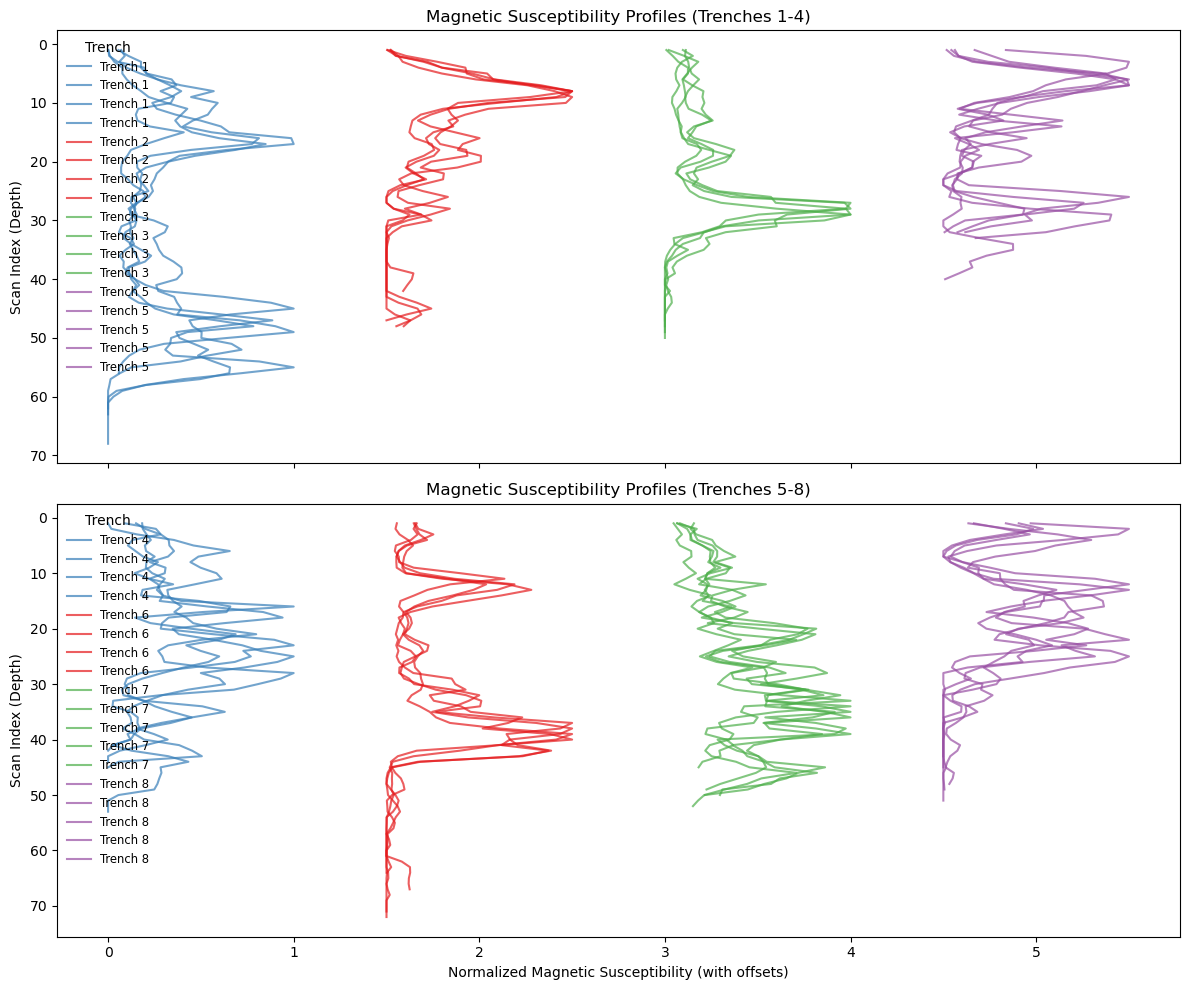

In [18]:
# Example data creation for demonstration (you can remove this part)
# Replace this with your actual DataFrame loading step
# magsus = pd.DataFrame({
#     'record_id': np.repeat(np.arange(1, 9), 100),
#     'trench_id': np.repeat(np.arange(1, 9), 100),
#     'scan_idx': np.tile(np.arange(1, 101), 8),
#     'susceptibility': np.random.rand(800)
# })

# Assuming magsus DataFrame is already created with the following columns:
# 'record_id', 'trench_id', 'scan_idx', 'susceptibility'

# Define a colorblind-friendly palette for 8 trenches
colors = ['#377eb8', '#e41a1c', '#4daf4a', '#984ea3', '#ff7f00', '#ffff33', '#a65628', '#f781bf']

# Normalize susceptibility values for each record
def normalize_susceptibility(data):
    data['susceptibility'] = data.groupby('record_id')['susceptibility'].transform(lambda x: x / x.max())
    return data

# Normalize the magsus DataFrame
magsus = normalize_susceptibility(magsus)

# Separate trenches into two groups for plotting
trench_groups = magsus['trench_id'].unique()
trench_group1 = trench_groups[:4]  # First 4 trenches
trench_group2 = trench_groups[4:]  # Last 4 trenches

# Create a figure and two subplots
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=True)

# Function to plot each group
def plot_trench_group(ax, trench_group, data, colors):
    for i, trench in enumerate(trench_group):
        trench_data = data[data['trench_id'] == trench]
        
        # Get unique record IDs for this trench
        record_ids = trench_data['record_id'].unique()
        
        # Horizontal offset for separating trenches
        offset = i * 1.5  # Adjust spacing as needed
        
        for record_id in record_ids:
            record_data = trench_data[trench_data['record_id'] == record_id]
            
            # Plot each profile with an offset and transparency
            ax.plot(record_data['susceptibility'] + offset,
                    record_data['scan_idx'],
                    label=f'Trench {trench}',
                    color=colors[i],
                    alpha=0.7)  # Transparency
            
    ax.invert_yaxis()  # Invert y-axis to have depth increase downward
    ax.set_ylabel('Scan Index (Depth)')
    ax.legend(title='Trench', loc='upper left', fontsize='small', frameon=False)

# Plot the first group of trenches
plot_trench_group(axs[0], trench_group1, magsus, colors)
axs[0].set_title('Magnetic Susceptibility Profiles (Trenches 1-4)')

# Plot the second group of trenches
plot_trench_group(axs[1], trench_group2, magsus, colors)
axs[1].set_title('Magnetic Susceptibility Profiles (Trenches 5-8)')
axs[1].set_xlabel('Normalized Magnetic Susceptibility (with offsets)')

# Adjust the layout and show the plot
plt.tight_layout()
plt.show()



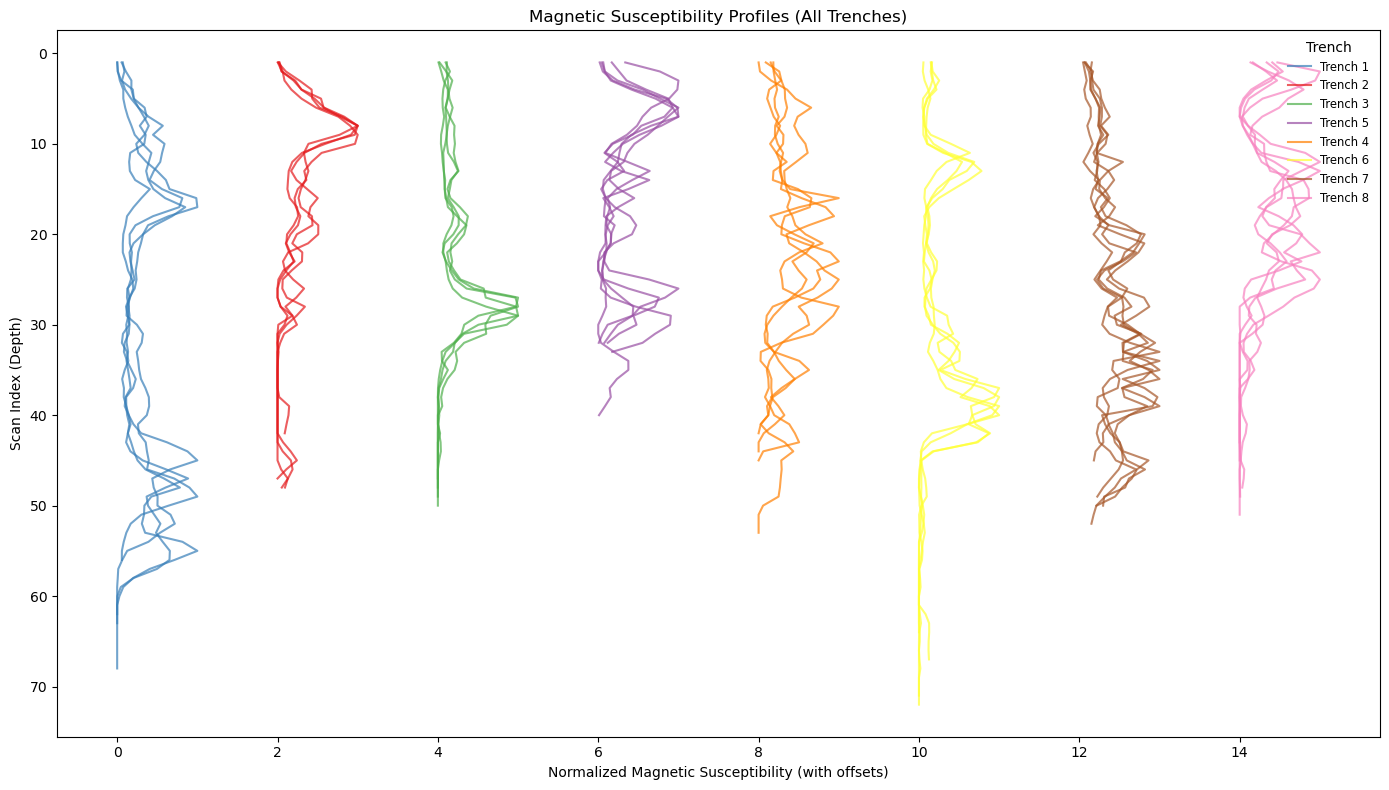

In [21]:
# Example data creation for demonstration (you can remove this part)
# Replace this with your actual DataFrame loading step
# magsus = pd.DataFrame({
#     'record_id': np.repeat(np.arange(1, 9), 100),
#     'trench_id': np.repeat(np.arange(1, 9), 100),
#     'scan_idx': np.tile(np.arange(1, 101), 8),
#     'susceptibility': np.random.rand(800)
# })

# Assuming magsus DataFrame is already created with the following columns:
# 'record_id', 'trench_id', 'scan_idx', 'susceptibility'

# Define a colorblind-friendly palette for 8 trenches
colors = ['#377eb8', '#e41a1c', '#4daf4a', '#984ea3', '#ff7f00', '#ffff33', '#a65628', '#f781bf']

# Normalize susceptibility values for each record
def normalize_susceptibility(data):
    data['susceptibility'] = data.groupby('record_id')['susceptibility'].transform(lambda x: x / x.max())
    return data

# Normalize the magsus DataFrame
magsus = normalize_susceptibility(magsus)

# Create a figure
fig, ax = plt.subplots(figsize=(14, 8))

# Plot each trench
for i, trench in enumerate(magsus['trench_id'].unique()):
    trench_data = magsus[magsus['trench_id'] == trench]
    
    # Get unique record IDs for this trench
    record_ids = trench_data['record_id'].unique()
    
    # Horizontal offset for separating trenches
    offset = i * 2  # Adjust spacing as needed
    
    for record_id in record_ids:
        record_data = trench_data[trench_data['record_id'] == record_id]
        
        # Plot each profile with an offset and transparency
        ax.plot(record_data['susceptibility'] + offset,
                record_data['scan_idx'],
                label=f'Trench {trench}' if record_id == record_ids[0] else "",
                color=colors[i],
                alpha=0.7)  # Transparency

ax.invert_yaxis()  # Invert y-axis to have depth increase downward
ax.set_ylabel('Scan Index (Depth)')
ax.set_xlabel('Normalized Magnetic Susceptibility (with offsets)')
ax.set_title('Magnetic Susceptibility Profiles (All Trenches)')

# Create a custom legend for trenches
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title='Trench', loc='upper right', fontsize='small', frameon=False)

# Adjust the layout and show the plot
plt.tight_layout()

# save the plot
plt.savefig('../Output/magnetic_susceptibility_profiles.png', dpi=300, bbox_inches='tight', format='png')

# Display it
plt.show()
